<a href="https://colab.research.google.com/github/harishmk31/24ADI003_24BAD031/blob/main/scenario1_exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harish MK - 24BAD031
     support            itemsets
85  0.458184        (whole milk)
52  0.376603  (other vegetables)
64  0.349666        (rolls/buns)
73  0.313494              (soda)
86  0.282966            (yogurt)
                       antecedents         consequents   support  confidence  \
0               (other vegetables)        (whole milk)  0.191380    0.508174   
1                     (whole milk)  (other vegetables)  0.191380    0.417693   
2                     (whole milk)        (rolls/buns)  0.178553    0.389698   
3                     (rolls/buns)        (whole milk)  0.178553    0.510638   
4                     (whole milk)              (soda)  0.151103    0.329787   
..                             ...                 ...       ...         ...   
863                (specialty bar)        (rolls/buns)  0.020010    0.380488   
864       (rolls/buns, newspapers)   (root vegetables)  0.020010    0.349776   
865  (newspapers, root vegetables)        (rolls/buns)  0.020

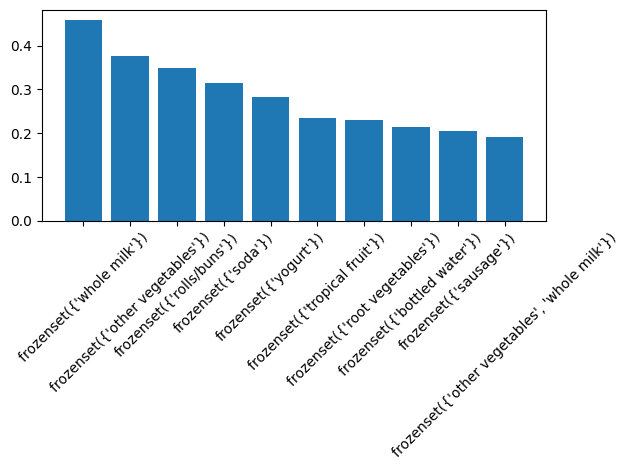

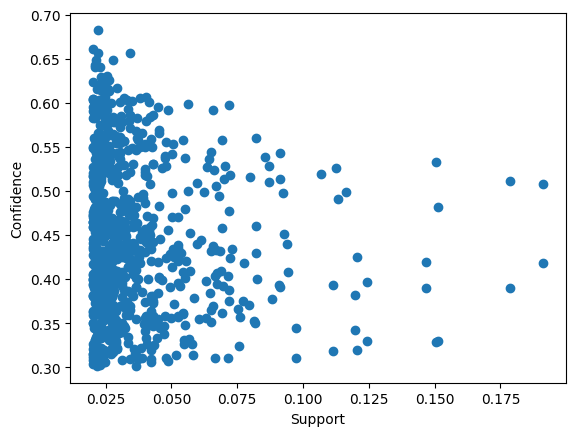

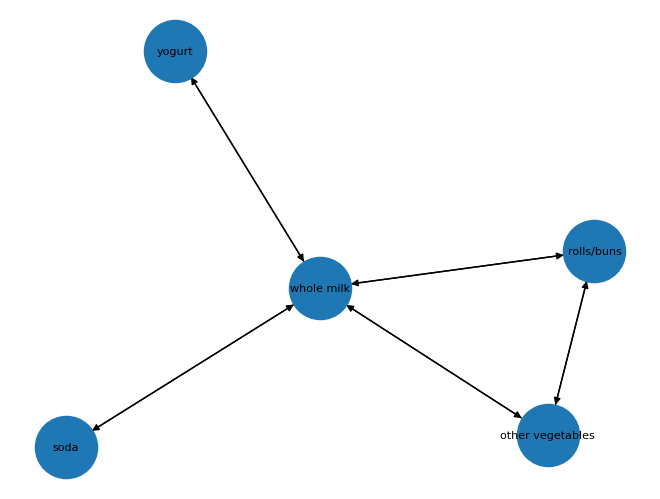

Frequent items are often bought together
High lift shows strong association
Useful for recommendations and store layout


In [5]:
print("Harish MK - 24BAD031")

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx

data = pd.read_csv("Groceries_dataset.csv")

transactions = data.groupby('Member_number')['itemDescription'].apply(list).values.tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

min_support = 0.02
frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
rules = rules[(rules['lift'] > 1) & (rules['confidence'] > 0.3)]

print(frequent_itemsets.head())
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

for _, row in rules.head(5).iterrows():
    print(f"If {set(row['antecedents'])} then {set(row['consequents'])} | Conf: {row['confidence']:.2f} Lift: {row['lift']:.2f}")

print("Average Support:", rules['support'].mean())
print("Average Confidence:", rules['confidence'].mean())
print("Average Lift:", rules['lift'].mean())

supports = [0.01, 0.02, 0.05]
for s in supports:
    fi = apriori(df, min_support=s, use_colnames=True)
    print(s, len(fi))

conf_levels = [0.2, 0.4, 0.6]
for c in conf_levels:
    r = association_rules(frequent_itemsets, metric="confidence", min_threshold=c)
    print(c, len(r))

top_items = frequent_itemsets.head(10)

plt.figure()
plt.bar(range(len(top_items)), top_items['support'])
plt.xticks(range(len(top_items)), top_items['itemsets'].astype(str), rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.show()

G = nx.DiGraph()

for _, row in rules.head(10).iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['lift'])

plt.figure()
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, font_size=8)
plt.show()

print("Frequent items are often bought together")
print("High lift shows strong association")
print("Useful for recommendations and store layout")